In [79]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
from scaleagdata_vito.presto.datasets import ScaleAgDataset
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import train_test_val_split, evaluate_finetuned_model
from sklearn.metrics import classification_report

def plot_predicted_vs_true(y_true, y_pred, ax, title):
    ax.scatter(y_true, y_pred)
    # ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    ax.set_xlabel("True Yield kg/H")
    ax.set_ylabel("Predicted Yield kg/H")
    ax.set_title(title)

In [51]:
# Dataset Parameters
composite_window="month"
unique_id_column="Field_ID"
old_data_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_05112025/polygons/{composite_window}/"
data_2023_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_24022026/polygons/{composite_window}/"
new_data_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_04022026/polygons/{composite_window}/"

In [53]:
ref_id = 'Maize_2021_5mbuffered'
extractions_2021 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2021-07-01", "2021-11-30"],
)
ref_id = 'Maize_2022_5mbuffered'
extractions_2022 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2022-07-01", "2022-11-30"],
)
ref_id = 'Maize_2023_5mbuffered'
extractions_2023 = load_dataset(
    str(Path(data_2023_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2023-07-01", "2023-11-30"],
)
ref_id = 'tamale_30field_2025_5mbuffer'
extractions_2025 = load_dataset(
    str(Path(new_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2025-07-01", "2025-11-30"],
)


  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:744: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["start_date"] = window_of_interest[0]
/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["end_date"] = window_of_interest[1]
  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/

#### Data investigation

In [54]:
# Print min and max of yield distribution for each year
th = 6000
extractions_2022 = extractions_2022[extractions_2022['Yield kg/H'] < th].reset_index(drop=True)
datasets = [extractions_2021, extractions_2022, extractions_2023, extractions_2025]
years = [2021, 2022, 2023, 2025]

for i, (dataset, year) in enumerate(zip(datasets, years)):
    min_yield = dataset['Yield kg/H'].min()
    max_yield = dataset['Yield kg/H'].max()
    print(f"Year {year}: Min = {min_yield:.2f} kg/H, Max = {max_yield:.2f} kg/H")


Year 2021: Min = 190.70 kg/H, Max = 3446.10 kg/H
Year 2022: Min = 226.60 kg/H, Max = 4792.60 kg/H
Year 2023: Min = 901.10 kg/H, Max = 6352.20 kg/H
Year 2025: Min = 785.55 kg/H, Max = 2830.45 kg/H


In [56]:
for y in years:
    datasets[years.index(y)]['year'] = y
extractions = pd.concat(datasets, ignore_index=True)
target_column = "Yield kg/H"
extractions["Field_ID_year"] = extractions['Field_ID'] + "_" + extractions['year'].astype(str)
extractions['REGION'] = extractions['REGION'].apply(lambda x: 'Northern' if x != 'Savanna' else 'Savanna')
extractions['DISTRICT'] = extractions['DISTRICT'].apply(lambda x: x.split('\n')[0].upper())
extractions['COMMUNITY'] = extractions['COMMUNITY'].apply(lambda x: x.upper())

In [57]:
extractions[unique_id_column] = extractions[unique_id_column].astype(str) + "_" + extractions['year'].astype(str)

In [58]:
import matplotlib.pyplot as plt

def plot_distribution(train_df, test_df, val_df, target_column):
    # Create a figure with subplots for the value counts including train/test/val splits
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Distribution of Variables by Train/Test/Validation Split', fontsize=16)

    # Define colors for train/test/val
    colors = ['blue', 'orange', 'green']
    labels = ['Train', 'Test', 'Val']
    datasets = [train_df, test_df, val_df]

    # REGION distribution
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        region_counts = data.REGION.value_counts()
        axes[0, 0].bar(region_counts.index, region_counts.values, alpha=0.7, color=color, label=label)
    axes[0, 0].set_title('REGION')
    axes[0, 0].set_xlabel('Region')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()

    # COMMUNITY distribution
    all_communities = pd.concat(datasets).COMMUNITY.unique()
    x_pos = range(len(all_communities))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        community_counts = data.COMMUNITY.value_counts().reindex(all_communities, fill_value=0)
        axes[0, 1].bar([x + i*0.25 for x in x_pos], community_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[0, 1].set_title('COMMUNITY')
    axes[0, 1].set_xlabel('Community')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_xticks([x + 0.25 for x in x_pos])
    axes[0, 1].set_xticklabels(all_communities, rotation=45, ha='right')
    axes[0, 1].legend()

    # DISTRICT distribution
    all_districts = pd.concat(datasets).DISTRICT.unique()
    x_pos_district = range(len(all_districts))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        district_counts = data.DISTRICT.value_counts().reindex(all_districts, fill_value=0)
        axes[1, 0].bar([x + i*0.25 for x in x_pos_district], district_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 0].set_title('DISTRICT')
    axes[1, 0].set_xlabel('District')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_xticks([x + 0.25 for x in x_pos_district])
    axes[1, 0].set_xticklabels(all_districts, rotation=45, ha='right')
    axes[1, 0].legend()

    # YEAR distribution
    all_years = sorted(pd.concat(datasets).year.unique())
    x_pos_year = range(len(all_years))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        year_counts = data.year.value_counts().reindex(all_years, fill_value=0)
        axes[1, 1].bar([x + i*0.25 for x in x_pos_year], year_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 1].set_title('YEAR')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_xticks([x + 0.25 for x in x_pos_year])
    axes[1, 1].set_xticklabels(all_years)
    axes[1, 1].legend()

    # Yield kg/H histogram
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        axes[0, 2].hist(data[target_column].dropna(), alpha=0.7, bins=20, color=color, label=label)
    axes[0, 2].set_title('Yield kg/H')
    axes[0, 2].set_xlabel('Yield kg/H')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()

    # Bin mean yield and std plot
    bin_means = train_df.groupby('bin')['bin_mean_yield'].mean()
    bin_stds = train_df.groupby('bin')['bin_std_yield'].mean()
    bins = bin_means.index.astype(str)
    axes[1, 2] = fig.add_subplot(2, 3, 6)
    axes[1, 2].bar(bins, bin_means.values, yerr=bin_stds.values, capsize=5, color='skyblue', alpha=0.8)
    axes[1, 2].set_title('Bin Mean Yield ± Std')
    axes[1, 2].set_xlabel('Bin')
    axes[1, 2].set_ylabel('Mean Yield (kg/H)')
    # # Remove the empty subplot
    # axes[1, 2].remove()

    plt.tight_layout()
    plt.show()

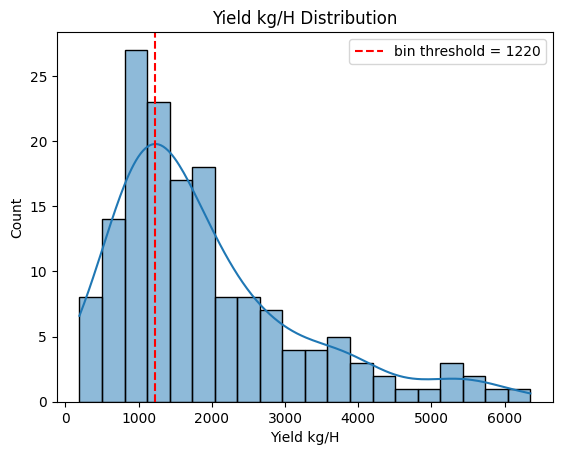

In [70]:
import seaborn as sns
bin_th = 1220
sns.histplot(extractions['Yield kg/H'], bins=20, kde=True)
plt.axvline(bin_th, color='red', linestyle='--', label=f"bin threshold = {str(bin_th)}")
plt.title('Yield kg/H Distribution')
plt.legend()
plt.show()



### Binarize target

In [71]:
from sklearn.model_selection import train_test_split

# Create bins for stratification based on the parent group's median yield
extractions['bin'] = extractions[target_column].apply(lambda x: 0 if x < bin_th else 1)

# Filter out yield bins with less than 3 samples to avoid stratification issues
bin_counts = extractions['bin'].value_counts()
valid_bins = bin_counts[bin_counts >= 3].index
extractions_filtered = extractions[extractions['bin'].isin(valid_bins)]

# Compute mean and std of yield for each bin and add as columns
bin_stats = extractions.groupby('bin')[target_column].agg(['mean', 'std']).rename(columns={'mean': 'bin_mean_yield', 'std': 'bin_std_yield'})
extractions = extractions.merge(bin_stats, left_on='bin', right_index=True, how='left')

print(f"Original parent groups: {len(extractions)}")
print(f"After filtering bins with <3 samples: {len(extractions_filtered)}")
print(f"Removed {len(extractions) - len(extractions_filtered)} parent groups")

# Get unique parentnames as our splitting units (from filtered data)
parentnames = extractions_filtered[unique_id_column].unique().tolist()
yield_bins = extractions_filtered['bin'].values

# First split: 80% train, 20% temp (for val and test)
train_parents, temp_parents = train_test_split(
    parentnames,
    train_size=0.8,
    stratify=yield_bins,
    random_state=42
)

# Get yield bins for temp parents and check if they still have enough samples for stratification
temp_bins = extractions_filtered[extractions_filtered[unique_id_column].isin(temp_parents)]['bin'].values
temp_bin_counts = pd.Series(temp_bins).value_counts()

# Check if any bin in temp set has less than 2 samples (minimum for stratification)
if (temp_bin_counts < 2).any():
    print("Warning: Some bins in temp set have <2 samples. Using random split instead of stratified split for val/test.")
    # Second split: split temp randomly into 50-50 for val and test
    val_parents, test_parents = train_test_split(
        temp_parents,
        train_size=0.5,
        random_state=42
    )
else:
    # Second split: split temp into 50-50 for val and test with stratification
    val_parents, test_parents = train_test_split(
        temp_parents,
        train_size=0.5,
        stratify=temp_bins,
        random_state=42
    )

# Create the final datasets by filtering on parentname
train_df = extractions[extractions[unique_id_column].isin(train_parents)]
val_df = extractions[extractions[unique_id_column].isin(val_parents)]
test_df = extractions[extractions[unique_id_column].isin(test_parents)]

print(f"Train set size: {len(train_df)} ({len(train_df)/len(extractions)*100:.1f}%)")
print(f"Validation set size: {len(val_df)} ({len(val_df)/len(extractions)*100:.1f}%)")
print(f"Test set size: {len(test_df)} ({len(test_df)/len(extractions)*100:.1f}%)")

# Verify no parentname overlap
assert len(set(train_df[unique_id_column]) & set(val_df[unique_id_column])) == 0
assert len(set(train_df[unique_id_column]) & set(test_df[unique_id_column])) == 0
assert len(set(val_df[unique_id_column]) & set(test_df[unique_id_column])) == 0
print(f"✓ No {unique_id_column} overlap between splits")

Original parent groups: 157
After filtering bins with <3 samples: 157
Removed 0 parent groups
Train set size: 125 (79.6%)
Validation set size: 16 (10.2%)
Test set size: 16 (10.2%)
✓ No Field_ID overlap between splits


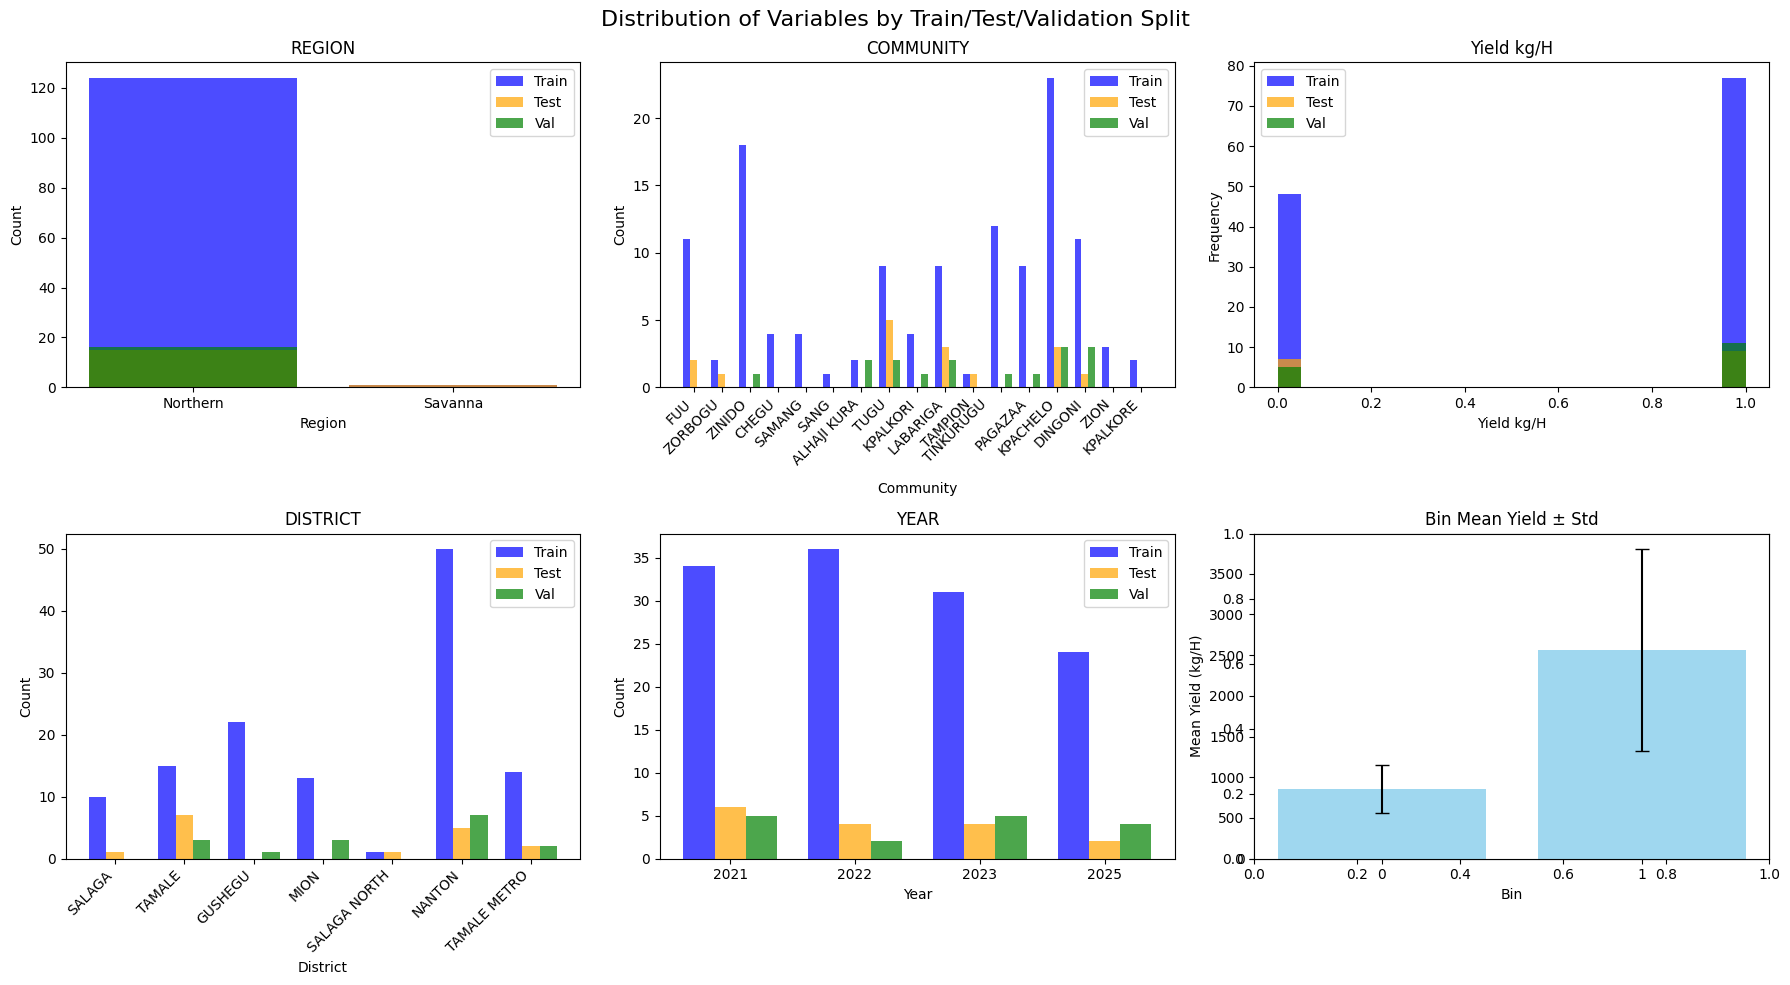

In [72]:
plot_distribution(train_df, test_df, val_df, 'bin')

##### Random Forest

In [73]:
target_column = 'bin'
# predict mean and evaluate based on std 

In [74]:
s2_cols = [col for col in extractions.columns if 'OPTICAL' in col]
s1_cols = [col for col in extractions.columns if 'SAR' in col]
dem_cols = [col for col in extractions.columns if 'DEM' in col]
meteo_cols = [col for col in extractions.columns if 'METEO' in col]
feature_columns = s2_cols + s1_cols + dem_cols + meteo_cols

In [75]:
X_train, y_train = train_df[feature_columns], train_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

In [76]:
import numpy as np 

X_train = X_train.replace(65535, np.nan)
X_val = X_val.replace(65535, np.nan)
X_test = X_test.replace(65535, np.nan)

In [81]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestClassifier(
        n_estimators=10,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        oob_score=True,
        warm_start=True
    ))
])

# Early stopping using validation set. this allows selecting the best n_estimators
best_val_score = -float('inf')
best_n_estimators = 10
patience = 5
no_improve = 0

for n_estimators in range(10, 101, 10):
    rf_pipe.named_steps['rf'].n_estimators = n_estimators
    rf_pipe.fit(X_train, y_train)
    val_score = rf_pipe.score(X_val, y_val)
    if val_score > best_val_score:
        best_val_score = val_score
        best_n_estimators = n_estimators
        no_improve = 0
    else:
        no_improve += 1
    if no_improve >= patience:
        break

# Refit with best n_estimators
rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestClassifier(
        n_estimators=best_n_estimators,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        oob_score=True,
        warm_start=True
    ))
])
rf_pipe.fit(X_train, y_train)

print("Accuracy on Train:", rf_pipe.score(X_train, y_train))
print("Accuracy on Val:", rf_pipe.score(X_val, y_val))
print("Accuracy on Test:", rf_pipe.score(X_test, y_test))

preds_train = rf_pipe.predict(X_train)
preds_val = rf_pipe.predict(X_val)
preds_test = rf_pipe.predict(X_test)

print(classification_report(y_test, preds_test))

Accuracy on Train: 0.992
Accuracy on Val: 0.8125
Accuracy on Test: 0.5625
              precision    recall  f1-score   support

           0       0.50      0.43      0.46         7
           1       0.60      0.67      0.63         9

    accuracy                           0.56        16
   macro avg       0.55      0.55      0.55        16
weighted avg       0.56      0.56      0.56        16



##### Catboost 

In [82]:
from catboost import CatBoostClassifier

cat_clf = CatBoostClassifier(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='Logloss',  # Use 'Logloss' for binary classification
        verbose=100
)

cat_clf.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=20
)

print("Accuracy on Train:", cat_clf.score(X_train, y_train))
print("Accuracy on Val:", cat_clf.score(X_val, y_val))
print("Accuracy on Test:", cat_clf.score(X_test, y_test))

preds_train = cat_clf.predict(X_train) 
preds_val = cat_clf.predict(X_val)
preds_test = cat_clf.predict(X_test)

print(classification_report(y_test, preds_test))


0:	learn: 0.6897914	test: 0.6913979	best: 0.6913979 (0)	total: 65ms	remaining: 32.4s
100:	learn: 0.4544577	test: 0.5611071	best: 0.5611071 (100)	total: 224ms	remaining: 885ms
200:	learn: 0.3241869	test: 0.4863070	best: 0.4863070 (200)	total: 387ms	remaining: 575ms
300:	learn: 0.2451747	test: 0.4586691	best: 0.4586691 (300)	total: 570ms	remaining: 377ms
400:	learn: 0.1870028	test: 0.4351246	best: 0.4351246 (400)	total: 766ms	remaining: 189ms
499:	learn: 0.1455959	test: 0.4121976	best: 0.4121976 (499)	total: 953ms	remaining: 0us

bestTest = 0.4121976459
bestIteration = 499

Accuracy on Train: 0.992
Accuracy on Val: 0.8125
Accuracy on Test: 0.6875
              precision    recall  f1-score   support

           0       0.67      0.57      0.62         7
           1       0.70      0.78      0.74         9

    accuracy                           0.69        16
   macro avg       0.68      0.67      0.68        16
weighted avg       0.69      0.69      0.68        16



##### Presto

In [83]:
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
task_type = "binary"
target_name= "bin"

In [84]:
train_ds = ScaleAgDataset(
    dataframe=train_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

In [85]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path("/home/giorgia/Private/data/geomaize/models/")
experiment_name = f"presto-scaleag-ft-{composite_window}-geomaize-bin"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32  # Back to original batch size
num_workers = 0
max_epochs = 200  # Keep reasonable number of epochs
patience = 30  # More patience for convergence
freeze_layers = ['encoder']
unfreeze_epoch = 200  # Keep early unfreezing

In [19]:
# model = PretrainedPrestoWrapper(
#     num_outputs=num_outputs,
#     regression=False,
#     pretrained_model_path=pretrained_model_path,
# )
# model = load_presto_weights(model, pretrained_model_path, strict=False)

In [87]:
from scaleagdata_vito.presto.utils import get_pretrained_model_url
loss_fn = nn.BCEWithLogitsLoss()
pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
# pretrained_model_path = Path("/home/giorgia/Private/models_FSL/scaleag/Presto_FTS_ADaM_MedianYield_01-fulldataset_10bins_v1.pt")
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
        pretrained_model_path=pretrained_model_path,
    )

end_lr = 1e-5
start_lr = 1e-3
drop_factor = end_lr / start_lr
parameters = param_groups_lrd(model)
optimizer = AdamW(parameters, lr=start_lr)
for group in optimizer.param_groups:
    group["initial_lr"] = start_lr

hyperparams = Hyperparams(
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers,
    lr=start_lr,
)

scheduler_head = lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=unfreeze_epoch)
scheduler_warmup = lr_scheduler.LinearLR(optimizer, start_factor=0.1 * drop_factor, end_factor=drop_factor, total_iters=3)
scheduler_final = lr_scheduler.LambdaLR(
                                optimizer,
                                lr_lambda=lambda step: drop_factor * (0.99**step),
                                )
scheduler = lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[scheduler_head, scheduler_warmup, scheduler_final],
    milestones=[unfreeze_epoch, unfreeze_epoch+3],
)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)
val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

finetuned_model = finetune.run_finetuning(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    experiment_name=experiment_name,
    output_dir=model_output_dir,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    hyperparams=hyperparams,
    setup_logging=False,  # Already setup logging
    freeze_layers=freeze_layers,
    unfreeze_epoch=unfreeze_epoch,
)

2026-02-24 17:10:43.692 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/data/geomaize/models/presto-scaleag-ft-month-geomaize-bin
2026-02-24 17:10:43.694 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.pos_embed
2026-02-24 17:10:43.694 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.weight
2026-02-24 17:10:43.695 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.bias
2026-02-24 17:10:43.695 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.weight
2026-02-24 17:10:43.696 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.bias
2026-02-24 17:10:43.696 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_Red_Edge.weight
2026-02-24 17:10:43.696 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.

Finetuning:   0%|          | 0/200 [00:00<?, ?it/s]

Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-24 17:10:43.892 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/200: Epoch 1/200 | Train Loss: 0.7197 | Val Loss: 0.6249 | Best Loss: 0.6249 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

...

2026-02-24 17:10:48.731 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 29/200: Epoch 29/200 | Train Loss: 0.6667 | Val Loss: 0.6352 | Best Loss: 0.6249 (no improvement for 28 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-24 17:10:48.853 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 30/200: Epoch 30/200 | Train Loss: 0.6637 | Val Loss: 0.6335 | Best Loss: 0.6249 (no improvement for 29 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-24 17:10:49.286 | INFO     | prometheo.finetune:_train_loop:161 - Early stopping!
2026-02-24 17:10:49.439 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


In [89]:
# Get predictions for train and validation sets as well
train_metrics, train_preds, train_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics, val_preds, val_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

metrics, preds, targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

print(metrics)

2026-02-24 17:13:37.299 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on binary task
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels w

{'0': {'f1-score': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 48.0},
 '1': {'f1-score': 0.7623762376237624,
       'precision': 0.616,
       'recall': 1.0,
       'support': 77.0},
 'accuracy': 0.616,
 'macro avg': {'f1-score': 0.3811881188118812,
               'precision': 0.308,
               'recall': 0.5,
               'support': 125.0},
 'weighted avg': {'f1-score': 0.4696237623762376,
                  'precision': 0.379456,
                  'recall': 0.616,
                  'support': 125.0}}
{'0': {'f1-score': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 5.0},
 '1': {'f1-score': 0.8148148148148148,
       'precision': 0.6875,
       'recall': 1.0,
       'support': 11.0},
 'accuracy': 0.6875,
 'macro avg': {'f1-score': 0.4074074074074074,
               'precision': 0.34375,
               'recall': 0.5,
               'support': 16.0},
 'weighted avg': {'f1-score': 0.5601851851851851,
                  'precision': 0.47265625,
                  'recall': 0.6875

/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

##### Presto + Catboost 

In [92]:
from scaleagdata_vito.presto.utils import get_encodings
from torch.utils.data import DataLoader

pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
# pretrained_model_path = Path("/home/giorgia/Private/models_FSL/scaleag/Presto_FTS_ADaM_MedianYield_01-fulldataset_10bins_v1.pt")
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
        pretrained_model_path=pretrained_model_path,
    )

all_encodings, all_targets = get_encodings(
    DataLoader(
        train_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ), 
    model)

all_encodings_val, all_targets_val = get_encodings(
    DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model
)

all_encodings_test, all_targets_test = get_encodings(
    DataLoader(
        test_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model   
)

cat_enc_pipe = CatBoostClassifier(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='Logloss',  # Use 'Logloss' for binary classification
        verbose=100
    )

cat_enc_pipe.fit(
    all_encodings, all_targets,
    eval_set=(all_encodings_val, all_targets_val),
    early_stopping_rounds=20
    )

print("Accuacy on Train:", cat_enc_pipe.score(all_encodings, all_targets))
print("Accuracy on Val:", cat_enc_pipe.score(all_encodings_val, all_targets_val))
print("Accuracy on Test:", cat_enc_pipe.score(all_encodings_test, all_targets_test))

preds_test = cat_enc_pipe.predict(all_encodings_test)
print(classification_report(all_targets_test, preds_test))

0:	learn: 0.6902636	test: 0.6910140	best: 0.6910140 (0)	total: 8.23ms	remaining: 4.11s
100:	learn: 0.4361319	test: 0.5406076	best: 0.5406076 (100)	total: 372ms	remaining: 1.47s
200:	learn: 0.3025562	test: 0.4809795	best: 0.4809795 (200)	total: 749ms	remaining: 1.11s
300:	learn: 0.2227998	test: 0.4435869	best: 0.4433919 (298)	total: 1.11s	remaining: 732ms
400:	learn: 0.1697487	test: 0.4196781	best: 0.4196533 (399)	total: 1.48s	remaining: 366ms
499:	learn: 0.1298206	test: 0.3887025	best: 0.3883416 (497)	total: 2.12s	remaining: 0us

bestTest = 0.3883415912
bestIteration = 497

Shrink model to first 498 iterations.
Accuacy on Train: 0.992
Accuracy on Val: 0.8125
Accuracy on Test: 0.625
              precision    recall  f1-score   support

         0.0       0.67      0.29      0.40         7
         1.0       0.62      0.89      0.73         9

    accuracy                           0.62        16
   macro avg       0.64      0.59      0.56        16
weighted avg       0.64      0.62    